In [1]:
import sys
print(sys.executable)

import cv2
print(cv2.__version__)


c:\Users\Grace\.venv\Scripts\python.exe
4.12.0


In [4]:
import pandas as pd
import os
from pathlib import Path

#Setting the path
REPO_NAME = "earthwatch-cnn"
BASE_DIR = next(
    p for p in Path.cwd().parents
    if p.name == REPO_NAME)
DATA_DIR = BASE_DIR / "data"

#Loading the data
data = pd.read_excel(DATA_DIR / "merged_metadata.xlsx")

In [3]:
# luke added this because the merged spreadsheet has explicit pathing to grace's computer for image_path

from pathlib import Path

IMAGE_DIR = DATA_DIR / "Great_UK_WaterBlitz"

# Replace Grace's machine path with yours
data["image_path"] = data["image_path"].apply(lambda p: IMAGE_DIR / Path(p).name)


In [5]:
# Check total count and class balance
print(f"Total images found: {len(data)}")
print(data['feedback_score'].value_counts())

Total images found: 9004
feedback_score
3    3873
1    3259
2    1872
Name: count, dtype: int64


In [6]:
import cv2
import numpy as np
from sklearn.model_selection import train_test_split

IMG_SIZE = (224, 224)

def valid_image(path):
    img = cv2.imread(path)
    return img is not None

print("Before valid_image filter:", len(data))

data = data[data['image_path'].apply(valid_image)] # this line is relatively computationally expensive it seems

print("After valid_image filter:", len(data))
print(data['image_path'].head())

def load_image(path):
    img = cv2.imread(path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, IMG_SIZE)
    img = img.astype("float32") / 255.0
    return img

Before valid_image filter: 9004
After valid_image filter: 8996
0    C:/Users/Grace/Desktop/Earthwatch\Great_UK_Wat...
1    C:/Users/Grace/Desktop/Earthwatch\Great_UK_Wat...
2    C:/Users/Grace/Desktop/Earthwatch\Great_UK_Wat...
3    C:/Users/Grace/Desktop/Earthwatch\Great_UK_Wat...
4    C:/Users/Grace/Desktop/Earthwatch\Great_UK_Wat...
Name: image_path, dtype: object


In [7]:
print("data shape:", data.shape)
print(data.head())


data shape: (8996, 156)
         downloaded_utc          layer_title  \
0  2025-11-26T17:48:11Z  Great UK WaterBlitz   
1  2025-11-26T17:48:17Z  Great UK WaterBlitz   
2  2025-11-26T17:48:23Z  Great UK WaterBlitz   
3  2025-11-26T17:48:29Z  Great UK WaterBlitz   
4  2025-11-26T17:48:35Z  Great UK WaterBlitz   

                           layer_id  feature_object_id  \
0  735751c713b3460aa8041d47f55070d7                 12   
1  735751c713b3460aa8041d47f55070d7                 13   
2  735751c713b3460aa8041d47f55070d7                 15   
3  735751c713b3460aa8041d47f55070d7                 16   
4  735751c713b3460aa8041d47f55070d7                 17   

                      feature_global_id  geometry_x  geometry_y  \
0  f1a757f1-0d0d-4dc5-943d-d2c03e1ba78a   -4.011572   52.434782   
1  3ba0caef-1459-47ca-bcff-bb6a8b253ca4   -1.997459   53.932339   
2  9ab3ef19-b92e-495d-8330-e5cab4f52139   -0.490153   51.398517   
3  7065d44e-868d-41a8-bc29-3e380d44a284   -1.705773   53.341469   
4  

In [8]:
# Check
print(data.columns)

Index(['downloaded_utc', 'layer_title', 'layer_id', 'feature_object_id',
       'feature_global_id', 'geometry_x', 'geometry_y', 'attachment_id',
       'attachment_global_id', 'attachment_name',
       ...
       'feedback_score', 'County', 'RBD_NAME', 'MNCAT_NAME',
       'Nitrate (mg/L) MID', 'Phosphate (mg/L) MID', 'Photo URL', 'x', 'y',
       'image_path'],
      dtype='object', length=156)


In [ ]:
# POOR vs NOT POOR (poor vs. moderate & good)
# Load all images into an array
images = np.array([load_image(path) for path in data['image_path']])

# Convert labels to binary classification (0=poor, 1=not poor)
orig_labels = data['feedback_score'].values
labels = (orig_labels >= 2).astype(int)

label_key  = {0: "poor", 1: "not poor"} # THIS IS AN IMPORTANT DESIGN DECISION; GROUPS TOGETHER MODERATE AND GOOD


In [ ]:
# NOT GOOD vs. GOOD (poor & moderate vs. good)
# Load all images into an array
images = np.array([load_image(path) for path in data['image_path']])

# Convert labels to binary classification (0=not good, 1=good)
orig_labels = data['feedback_score'].values
labels = (orig_labels == 3).astype(int)

label_key  = {0: "not good", 1: "good"} # THIS IS AN IMPORTANT DESIGN DECISION; GROUPS TOGETHER MODERATE AND POOR

In [23]:
# Counts of each type in data
unique, counts = np.unique(labels, return_counts=True)
counts_dict = dict(zip(unique, counts))

print("Data Distribution")
for idx, count in counts_dict.items():
    print(f"{label_key[idx].capitalize()}: {count} images")

Data Distribution
Poor: 3258 images
Not poor: 5738 images


In [24]:
print("Number of images:", len(images))
print("Number of labels:", len(labels))


Number of images: 8996
Number of labels: 8996


In [25]:
# Split into train/test data
X_train, X_test, y_train, y_test = train_test_split(images, labels, stratify=labels, test_size=0.2, random_state=42)

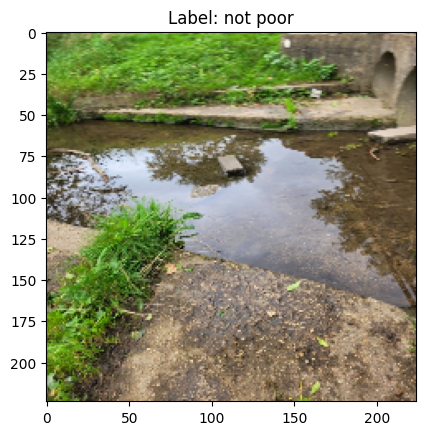

In [26]:
# Check
import matplotlib.pyplot as plt
plt.imshow(X_train[0])
plt.title(f"Label: {label_key[y_train[0]]}")
plt.show()

In [27]:
print("Unique y_train:", np.unique(y_train, return_counts=True))
print("Unique y_test:", np.unique(y_test, return_counts=True))


Unique y_train: (array([0, 1]), array([2606, 4590]))
Unique y_test: (array([0, 1]), array([ 652, 1148]))


In [28]:
from sklearn.model_selection import train_test_split
from sklearn.utils import class_weight
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, GlobalAveragePooling2D, Dense, Dropout, Input

# Weight image types (ie. so the CNN doesn't guess the most prominent label each time)
weights = class_weight.compute_class_weight(class_weight='balanced', classes=np.unique(y_train), y=y_train)
class_weights_dict = dict(enumerate(weights))

# Prevent overfitting with augmentation (water looks the same flipped, sunny vs. cloudy days)
def augment(image, label):
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_brightness(image, max_delta=0.1)
    # pixels stay within [0, 1] after brightness changes
    image = tf.clip_by_value(image, 0.0, 1.0) 
    return image, label

# Training Dataset - converts np array to tf dataset
train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train))
train_ds = train_ds.shuffle(len(X_train)).map(augment).batch(64).prefetch(tf.data.AUTOTUNE) #shuffles, augments, batches data for CNN

# Validation Dataset
val_ds = tf.data.Dataset.from_tensor_slices((X_test, y_test)).batch(64).prefetch(tf.data.AUTOTUNE)

# CNN
model = Sequential([
    Input(shape=(224, 224, 3)),
    Conv2D(32, (3, 3), activation='relu'), 
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D((2, 2)),
    GlobalAveragePooling2D(),
    Dense(128, activation='relu'),
    Dropout(0.5), # Dropout to prevent overfitting
    Dense(1, activation='sigmoid') # Binary output
])

# Compile/Train (tweak learning rate and epochs as needed)
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])

history = model.fit(train_ds, epochs=15, validation_data=val_ds, class_weight=class_weights_dict)

# Evaluate
test_loss, test_acc = model.evaluate(val_ds)
print(f"Test Accuracy: {test_acc}")

Epoch 1/15
113/113 ━━━━━━━━━━━━━━━━━━━━ 166s 1s/step - accuracy: 0.4341 - loss: 0.6943 - val_accuracy: 0.6378 - val_loss: 0.6880
Epoch 2/15
113/113 ━━━━━━━━━━━━━━━━━━━━ 137s 1s/step - accuracy: 0.5598 - loss: 0.6933 - val_accuracy: 0.6378 - val_loss: 0.6904
Epoch 3/15
113/113 ━━━━━━━━━━━━━━━━━━━━ 95s 839ms/step - accuracy: 0.5110 - loss: 0.6933 - val_accuracy: 0.4011 - val_loss: 0.6944
Epoch 4/15
113/113 ━━━━━━━━━━━━━━━━━━━━ 104s 915ms/step - accuracy: 0.5165 - loss: 0.6918 - val_accuracy: 0.4267 - val_loss: 0.7028
Epoch 5/15
113/113 ━━━━━━━━━━━━━━━━━━━━ 130s 1s/step - accuracy: 0.6092 - loss: 0.6938 - val_accuracy: 0.6378 - val_loss: 0.6894
Epoch 6/15
113/113 ━━━━━━━━━━━━━━━━━━━━ 137s 1s/step - accuracy: 0.5998 - loss: 0.6929 - val_accuracy: 0.6278 - val_loss: 0.6872
Epoch 7/15
113/113 ━━━━━━━━━━━━━━━━━━━━ 105s 930ms/step - accuracy: 0.5472 - loss: 0.6916 - val_accuracy: 0.4017 - val_loss: 0.7075
Epoch 8/15
113/113 ━━━━━━━━━━━━━━━━━━━━ 94s 832ms/step - accuracy: 0.5457 - loss: 0.6873 

In [30]:
# the code seemed to be missing this / messing this up before

history_dict = history.history

# check:
history_dict.keys()


dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

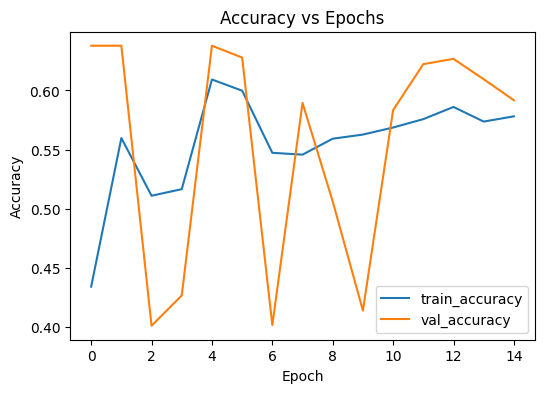

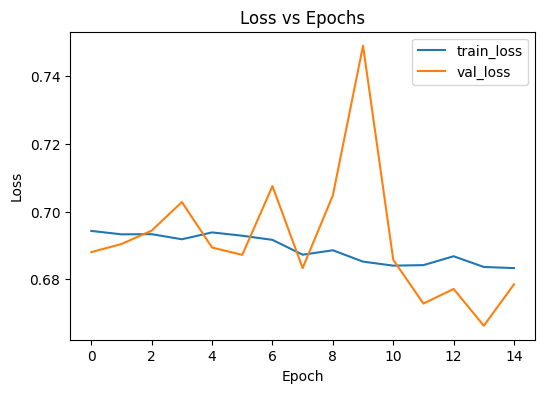

In [31]:
#Accuracy and Loss plots

import matplotlib.pyplot as plt

# Accuracy plot
acc = history_dict.get('accuracy', history_dict.get('acc', []))
val_acc = history_dict.get('val_accuracy', history_dict.get('val_acc', []))
plt.figure(figsize=(6,4))
plt.plot(acc, label='train_accuracy')
plt.plot(val_acc, label='val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Accuracy vs Epochs')
plt.show()

# Loss plot
loss = history_dict.get('loss', [])
val_loss = history_dict.get('val_loss', [])
plt.figure(figsize=(6,4))
plt.plot(loss, label='train_loss')
plt.plot(val_loss, label='val_loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Loss vs Epochs')
plt.show()

29/29 ━━━━━━━━━━━━━━━━━━━━ 5s 167ms/step
[[373 279]
 [456 692]]
              precision    recall  f1-score   support

        poor       0.45      0.57      0.50       652
    not poor       0.71      0.60      0.65      1148

    accuracy                           0.59      1800
   macro avg       0.58      0.59      0.58      1800
weighted avg       0.62      0.59      0.60      1800



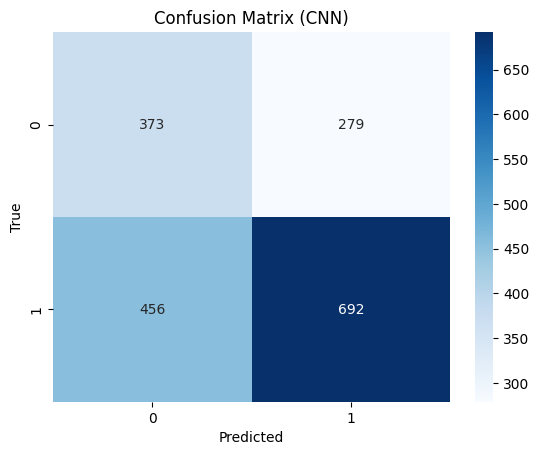

In [36]:
y_probs = model.predict(val_ds).ravel()
y_pred = (y_probs > 0.5).astype(int)

from sklearn.metrics import confusion_matrix, classification_report
print(confusion_matrix(y_test, y_pred))
# print(classification_report(y_test, y_pred, target_names=["not good", "good"])) # 0=not good; 1=good
print(classification_report(y_test, y_pred, target_names=["poor", "not poor"])) # 0=poor; 1=not poor

import seaborn as sns
plt.figure()
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix (CNN)")
plt.show()

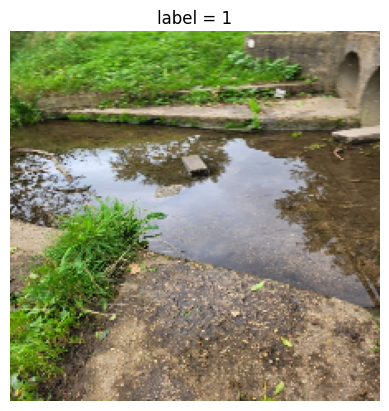

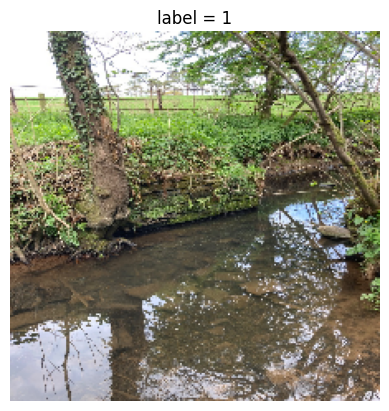

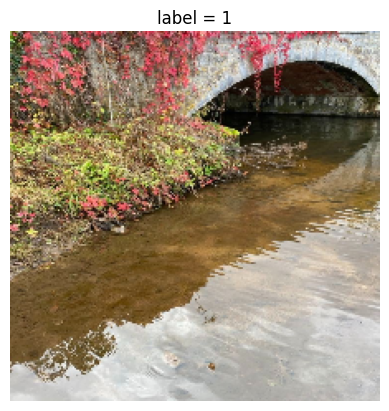

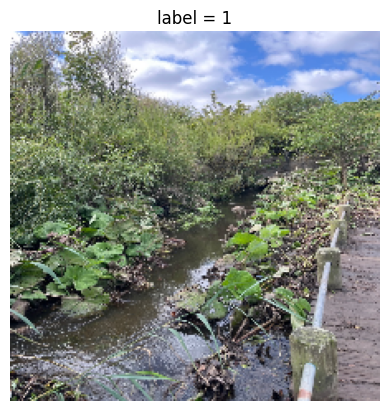

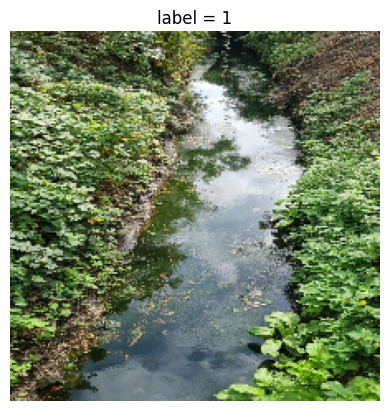

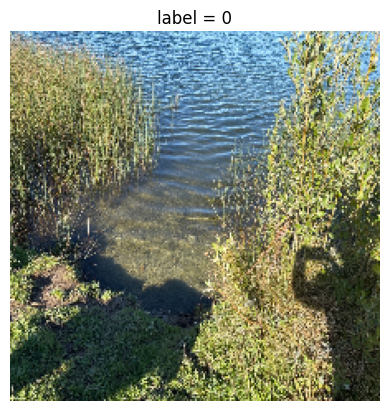

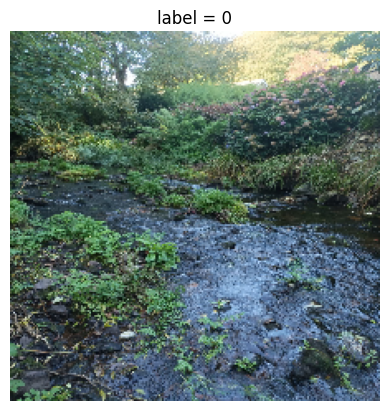

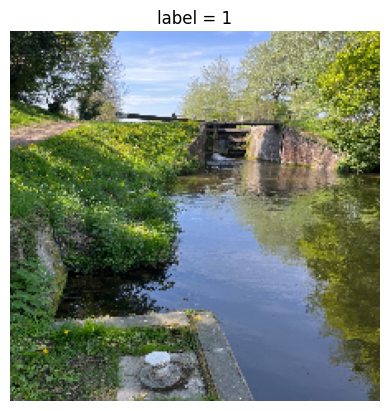

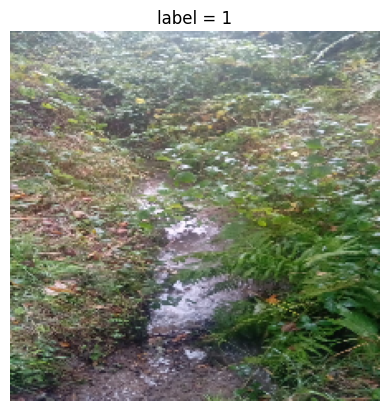

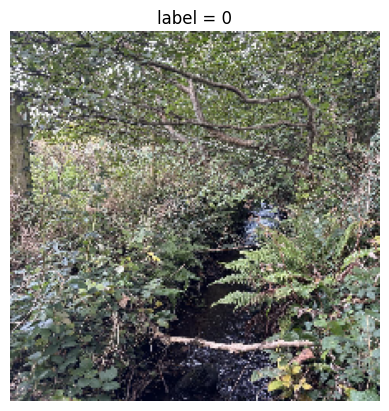

In [ ]:
# just to check: does this look like something a cnn could learn from? (these are ground truth)
### 1 = "not poor" (moderate or good)
### 0 = "poor"

import matplotlib.pyplot as plt

for i in range(10):
    plt.imshow(X_train[i])
    plt.title(f"label = {y_train[i]}")
    plt.axis("off")
    plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step


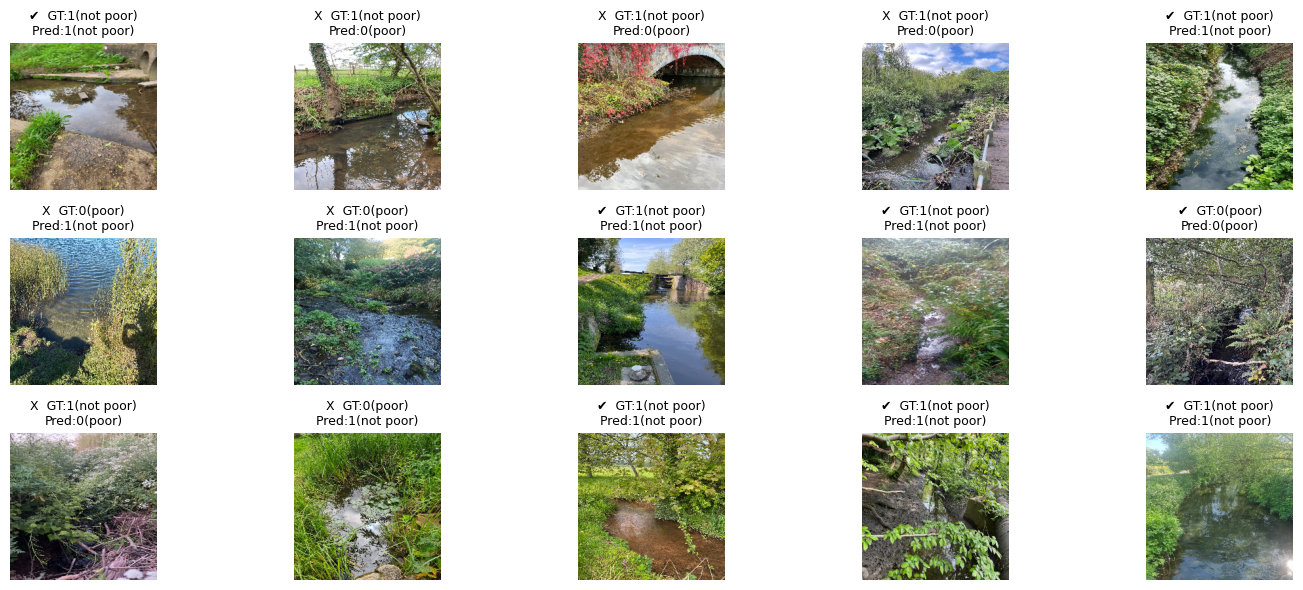

In [48]:
import matplotlib.pyplot as plt
import numpy as np

label_names = {0: "poor", 1: "not poor"}

# How many images to visualize
N = 15
rows, cols = 3, 5

probs = model.predict(X_train[:N]).ravel()
y_pred = (probs > 0.5).astype(int)

fig, axs = plt.subplots(rows, cols, figsize=(15, 6))

for idx in range(N):
    r = idx // cols
    c = idx % cols

    true_label = int(y_train[idx])
    pred_label = int(y_pred[idx])
    correct = (true_label == pred_label)
    symbol = "✔️" if correct else "X"

    ax = axs[r, c]
    ax.imshow(X_train[idx])
    ax.axis("off")
    ax.set_title(
        f"{symbol}  GT:{true_label}({label_names[true_label]})\n"
        f"Pred:{pred_label}({label_names[pred_label]})",
        fontsize=9
    )

plt.tight_layout()
plt.show()


In [ ]:
y_probs = model.predict(val_ds).ravel()
y_pred = (y_probs > 0.5).astype(int)

from sklearn.metrics import confusion_matrix, classification_report
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=["poor", "not poor"]))


29/29 ━━━━━━━━━━━━━━━━━━━━ 6s 203ms/step
[[369 283]
 [437 711]]
              precision    recall  f1-score   support

    not poor       0.46      0.57      0.51       652
        poor       0.72      0.62      0.66      1148

    accuracy                           0.60      1800
   macro avg       0.59      0.59      0.59      1800
weighted avg       0.62      0.60      0.61      1800

